In [ ]:
!pip install langchain
!pip install langgraph
!pip install langchain_openai

In [ ]:
from google.colab import userdata
import os
os.environ['OPENAI_API_KEY'] = userdata.get('openai')

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END
from operator import add
from langchain_openai import ChatOpenAI

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini",temperature=0.7)

In [ ]:
# State Schema
class Data(TypedDict):
  name:str
  ticket_raised:str
  department:str
  response:str
  mail:str

In [ ]:
import os
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from operator import add
from langchain_openai import ChatOpenAI


# Design my nodes
# classify

def classify(state:Data):
  state["department"]=llm.invoke(f"""you are a support assistant. Who will classify the given ticket into three classes:['product','billing'],
  Ticket:{state["ticket_raised"]},
  Answer with only the department name.""").content
  return state

In [ ]:
# create the first sub graph called product
product_graph= StateGraph(state_schema=Data)

In [ ]:
def product(state:Data):
  state["response"]=llm.invoke(f"you are a product support analyser based in the given ticket. Ticket:{state['ticket_raised']} create a single sentence quick response").content
  return state

In [ ]:
# Add node
product_graph.add_node("product", product)

# Add edges
product_graph.add_edge(START, "product")
product_graph.add_edge("product", END)

product_graph.set_entry_point("product")

# Compile
product_flow = product_graph.compile()

In [ ]:
product_graph.set_entry_point("product")

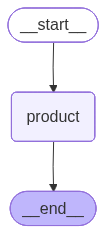

In [ ]:
product_flow

In [ ]:
# create the second sub graph called billing
billing_graph= StateGraph(state_schema=Data)
def billing(state:Data):
  state["response"]=llm.invoke(f"you are a billing support analyser based on the given ticket {state["ticket_raised"]} create a quick single sentence response").content
  return state

billing_graph.add_node("billing",billing)
billing_graph.add_edge(START,"billing")
billing_graph.add_edge("billing",END)
billing_graph.set_entry_point("billing")
billing_flow=billing_graph.compile()


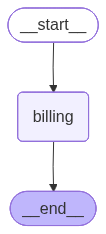

In [ ]:
billing_flow

In [ ]:
# main graph

def mail(state:Data):
  state["mail"]=llm.invoke(f"""you are a support assistant.create a polite response in the mail format with this name : {state["name"]} for the customer based on this:
  department:{state["department"]}
  action to be take: {state["response"]}.""").content
  return state

In [ ]:
main_graph=StateGraph(state_schema=Data)
main_graph.add_node("classify",classify)
main_graph.add_node("product",product_flow)
main_graph.add_node("billing",billing_flow)
main_graph.add_node("mail", mail) # Add mail node
def condition(state:Data):
    if state["department"]=="product":
        return "prod"
    else:
      return "bill"
main_graph.add_edge(START,"classify")
main_graph.add_conditional_edges("classify",condition,{"prod":"product","bill":"billing"})
main_graph.add_edge("product",mail)
main_graph.add_edge("billing",mail)

In [ ]:
so=main_graph.compile()

ValueError: Found edge ending at unknown node `<function mail at 0x7f9b3e332b60>`

In [ ]:
s

In [ ]:
import os
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI

# LLM
llm = ChatOpenAI(model="gpt-4o-mini")

# State Schema
class Data(TypedDict):
    name: str
    ticket_raised: str
    department: str
    response: str
    mail: str


# ------------------ CLASSIFIER ------------------
def classify(state: Data):
    state["department"] = llm.invoke(
        f"""You are a support assistant.
Classify the ticket into ['product','billing'].

Ticket: {state['ticket_raised']}

Answer ONLY with one word."""
    ).content.strip().lower()
    return state


# ------------------ PRODUCT SUBGRAPH ------------------
def product_node(state: Data):
    state["response"] = llm.invoke(
        f"You are a product support analyser. Ticket: {state['ticket_raised']}. Give a one-line response."
    ).content
    return state

product_graph = StateGraph(state_schema=Data)
product_graph.add_node("product", product_node)
product_graph.add_edge(START, "product")
product_graph.add_edge("product", END)
product_flow = product_graph.compile()


# ------------------ BILLING SUBGRAPH ------------------
def billing_node(state: Data):
    state["response"] = llm.invoke(
        f"You are a billing support analyser. Ticket: {state['ticket_raised']}. Give a one-line response."
    ).content
    return state

billing_graph = StateGraph(state_schema=Data)
billing_graph.add_node("billing", billing_node)
billing_graph.add_edge(START, "billing")
billing_graph.add_edge("billing", END)
billing_flow = billing_graph.compile()


# ------------------ MAIL NODE ------------------
def mail_node(state: Data):
    state["mail"] = llm.invoke(
        f"""Write a polite support email.

Customer Name: {state['name']}
Department: {state['department']}
Resolution: {state['response']}
"""
    ).content
    return state


# ------------------ MAIN GRAPH ------------------
main_graph = StateGraph(state_schema=Data)

main_graph.add_node("classify", classify)
main_graph.add_node("product", product_flow)
main_graph.add_node("billing", billing_flow)
main_graph.add_node("mail", mail_node)


# Condition
def condition(state: Data):
    if "product" in state["department"]:
        return "prod"
    else:
        return "bill"


# Edges
main_graph.add_edge(START, "classify")

main_graph.add_conditional_edges(
    "classify",
    condition,
    {
        "prod": "product",
        "bill": "billing"
    }
)

main_graph.add_edge("product", "mail")
main_graph.add_edge("billing", "mail")
main_graph.add_edge("mail", END)


# Compile
main_flow = main_graph.compile()

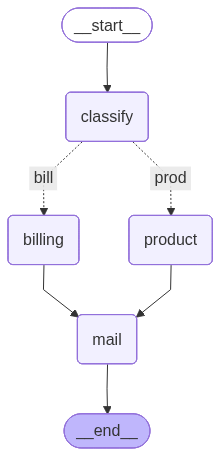

In [ ]:
main_flow

In [ ]:
result=main_flow.invoke({"name":"pradeep","ticket_raised":"I was charged two times while recharging for 180 rupees"})

In [ ]:
result

{'name': 'pradeep',
 'ticket_raised': 'I was charged two times while recharging for 180 rupees',
 'department': 'billing',
 'response': 'We apologize for the inconvenience; please provide your transaction details for us to assist you in resolving the double charge.',
 'mail': 'Subject: Assistance Required for Double Charge\n\nDear Pradeep,\n\nThank you for reaching out to our billing department. We sincerely apologize for any inconvenience you may have experienced regarding the double charge.\n\nTo assist you in resolving this matter as quickly as possible, could you please provide us with your transaction details? Information such as the date of the transaction, the amount charged, and any reference numbers would be extremely helpful.\n\nWe appreciate your cooperation and look forward to resolving this issue for you promptly.\n\nWarm regards,\n\n[Your Name]  \n[Your Job Title]  \n[Your Company]  \n[Your Contact Information]  \n[Company Website]  '}

In [ ]:
!pip install langsmith

In [ ]:
import os

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"] = "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"
os.environ["LANGCHAIN_PROJECT"] = "sub_graphs"

In [ ]:
!pip install langchain_core

In [ ]:
from langchain_core.tracers.context import tracing_v2_enabled

In [ ]:
from langsmith import traceable

In [ ]:
from langchain_core.tracers.context import tracing_v2_enabled

def tracking(var):
    with tracing_v2_enabled(project_name="sub_graphs"):
        return main_flow.invoke(var)

In [ ]:
tracking({"name":"pradeep","ticket_raised":"I was charged two times while recharging for 180 rupees"})

{'name': 'pradeep',
 'ticket_raised': 'I was charged two times while recharging for 180 rupees',
 'department': 'billing',
 'response': 'We apologize for the inconvenience; please check your transaction history and contact customer support for resolution.',
 'mail': 'Subject: Support for Your Billing Inquiry\n\nDear Pradeep,\n\nI hope this message finds you well. \n\nThank you for reaching out to us regarding your billing issue. We sincerely apologize for any inconvenience this may have caused you. To assist you better, we kindly ask you to check your transaction history for any discrepancies. \n\nIf you continue to have concerns or require further assistance, please do not hesitate to contact our customer support team. We are here to help and ensure that your issue is resolved promptly.\n\nThank you for your understanding.\n\nBest regards,\n\n[Your Name]  \n[Your Position]  \n[Company Name]  \n[Contact Information]  \n[Company Support Team]'}